In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import os
import psutil # Pastikan sudah install: pip install psutil

# Import dasar untuk SklearnWrapper
from sklearn.base import BaseEstimator, RegressorMixin

# Import model-model yang digunakan dalam base_estimators
from sklearn.ensemble import (StackingRegressor, RandomForestRegressor, 
                              ExtraTreesRegressor, GradientBoostingRegressor, 
                              AdaBoostRegressor)
from sklearn.linear_model import RidgeCV, Lasso
from sklearn.svm import SVR

# Import model pihak ketiga (pastikan sudah install: pip install xgboost lightgbm catboost)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

In [2]:
# 1. LOAD DATA
df = pd.read_excel('#1 final feature selected dataset 4 for nphr.xlsx')
X = df.drop(columns=['NPHR (Kcal/Kwh)'])
y = df['NPHR (Kcal/Kwh)']


In [3]:
df

,Coal Flow (t/h),Cold Reheat Pressure (Mpa),Flue gas temperature (℃),Temperature HRH,Cold Reheat Temperature (°C),Condenser vacuum (kPa),NPHR (Kcal/Kwh)
0,192.41,2.48,130.708067,566.36,322.19,-93.254772,2607.270106
1,181.37,2.28,129.803971,565.00,320.50,-93.319363,2687.121676
2,178.47,2.28,127.860081,565.63,320.80,-93.313517,2663.032090
3,172.09,2.21,129.812856,564.09,321.34,-93.346417,2651.943177
4,181.74,2.32,130.218360,565.75,320.44,-93.245120,2651.524408
...,...,...,...,...,...,...,...
544,172.99,2.43,124.009406,565.60,320.61,-92.739841,2362.587163
545,164.77,2.28,123.268547,565.79,322.63,-92.818141,2421.984297
546,169.38,2.25,124.640201,565.84,323.38,-93.038286,2522.739965
547,179.69,2.33,127.187321,566.30,323.13,-92.750339,2584.543200


In [4]:
# 2. SETUP EKSPERIMEN
sample_sizes = np.linspace(0.1, 1.0, 10) 
n_records = []
training_times = []
inference_times = []



In [5]:
# --- COMPATIBILITY WRAPPER (FIXED for sklearn 1.8.0 Tags system) ---
class SklearnWrapper(BaseEstimator, RegressorMixin):
    """Wrapper untuk kompatibilitas dengan sklearn StackingRegressor"""
    def __init__(self, model):
        self.model = model
    
    def fit(self, X, y, **fit_params):
        self.model.fit(X, y, **fit_params)
        return self
    
    def predict(self, X):
        return self.model.predict(X)
    
    def get_params(self, deep=True):
        return {"model": self.model}
    
    def set_params(self, **params):
        if "model" in params:
            self.model = params["model"]
        return self
    
    # Implement __sklearn_tags__ for proper regressor detection in sklearn 1.8.0+
    def __sklearn_tags__(self):
        from sklearn.utils._tags import Tags, RegressorTags, TargetTags, InputTags
        tags = Tags(
            estimator_type="regressor",
            target_tags=TargetTags(
                required=False,
                one_d_labels=False,
                two_d_labels=False,
                positive_only=False,
                multi_output=False,
                single_output=True
            ),
            regressor_tags=RegressorTags(),
            input_tags=InputTags()
        )
        return tags


# ==========================================
# 3. LOOPING UNTUK MENGUKUR WAKTU
# ==========================================
print(f"{'N':<8} | {'Train Time (s)':<15} | {'Inf Time (s)':<15}")
print("-" * 45)

# 3. LOOPING PENGUKURAN
for prop in sample_sizes:
    n = int(len(df) * prop)
    X_subset = X.iloc[:n]
    y_subset = y.iloc[:n]
    n_records.append(n)

    # ----------------------------------------------------
    # SETUP STACKING REGRESSOR
    # ----------------------------------------------------
    # 1. Definisikan Base Models (Sesuaikan dengan model di notebook Anda)
    # Contoh di bawah ini menggunakan Random Forest dan XGBoost
    base_estimators = [
   ('xgb', SklearnWrapper(xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42))),
    ('cat', SklearnWrapper(CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, verbose=0, random_state=42))),
    ('lgbm', SklearnWrapper(lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, verbosity=-1, random_state=42))),
    ('rf', RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)),
    ('et', ExtraTreesRegressor(n_estimators=300, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=300, random_state=42)),
    ('ada', AdaBoostRegressor(n_estimators=100, random_state=42)),
    ('svr', SklearnWrapper(SVR(C=1.0, epsilon=0.1))),
    ('lasso', Lasso(alpha=0.01))
    ]
    
    # 2. Definisikan Final Estimator (Meta-model)
    final_estimator = RidgeCV()
    
    # 3. Gabungkan ke dalam StackingRegressor
    model = StackingRegressor(
        estimators=base_estimators,
        final_estimator=final_estimator,
        cv=5 # Menggunakan 5-fold cross validation saat melatih meta-model
    )
    # ----------------------------------------------------
    
    # --- PENGUKURAN TRAINING ---
    start_train = time.time()
    model.fit(X_subset, y_subset)
    end_train = time.time()
    training_times.append(end_train - start_train)

    # --- PENGUKURAN INFERENCE (DETEKSI) ---
    start_inf = time.time()
    model.predict(X_subset)
    end_inf = time.time()
    inference_times.append(end_inf - start_inf)

    print(f"{n:<8} | {training_times[-1]:<15.4f} | {inference_times[-1]:<15.4f}")

N        | Train Time (s)  | Inf Time (s)   
---------------------------------------------
54       | 5.4224          | 0.0285         
109      | 5.7459          | 0.0275         
164      | 8.6768          | 0.0350         
219      | 5.6815          | 0.0386         
274      | 5.7394          | 0.0417         
329      | 6.3426          | 0.0470         
384      | 7.0945          | 0.0544         
439      | 7.5934          | 0.0605         
494      | 8.4859          | 0.0700         
549      | 9.5416          | 0.1060         


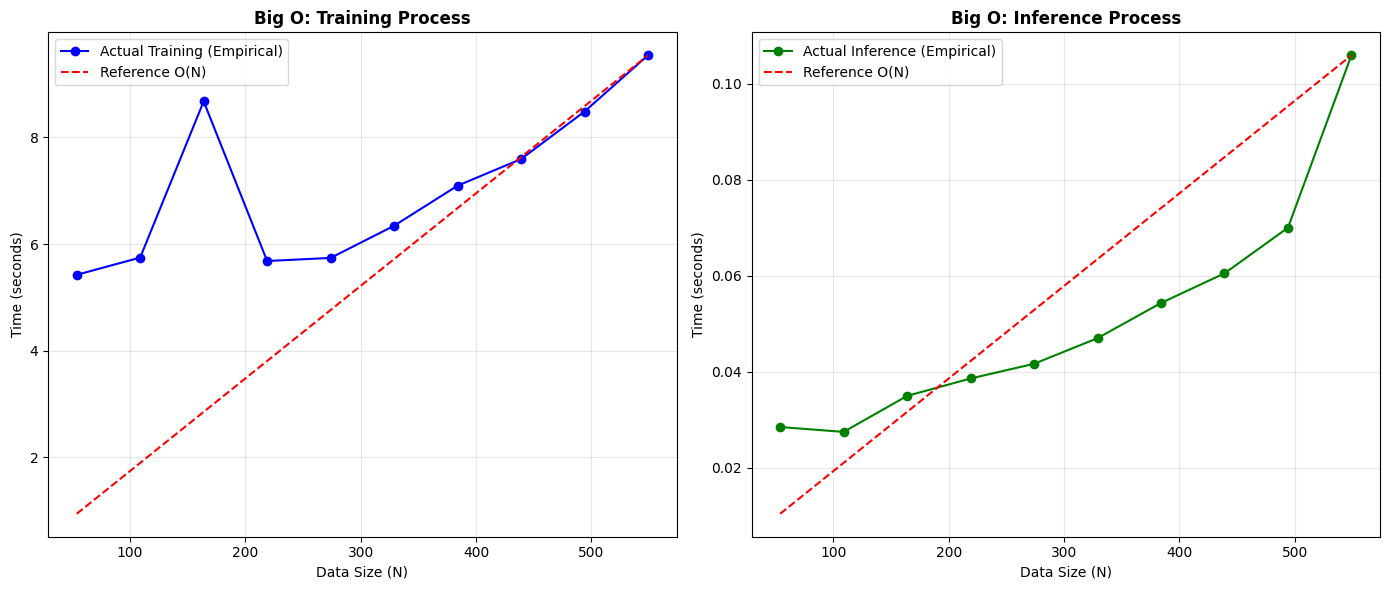

In [6]:
# 4. VISUALISASI PERBANDINGAN BIG O
plt.figure(figsize=(14, 6))

# Subplot 1: Training
plt.subplot(1, 2, 1)
plt.plot(n_records, training_times, 'bo-', label='Actual Training (Empirical)')
train_linear = [training_times[-1] * (n / n_records[-1]) for n in n_records]
plt.plot(n_records, train_linear, 'r--', label='Reference O(N)')
plt.title('Big O: Training Process', fontweight='bold')
plt.xlabel('Data Size (N)')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Inference
plt.subplot(1, 2, 2)
plt.plot(n_records, inference_times, 'go-', label='Actual Inference (Empirical)')
inf_linear = [inference_times[-1] * (n / n_records[-1]) for n in n_records]
plt.plot(n_records, inf_linear, 'r--', label='Reference O(N)')
plt.title('Big O: Inference Process', fontweight='bold')
plt.xlabel('Data Size (N)')
plt.ylabel('Time (seconds)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()